# Bilpay E-Wallet Transactions — Full Pipeline

```
┌──────────────┐    ┌──────────────┐    ┌──────────────┐    ┌──────────────┐
│  INGESTION   │ →  │     EDA      │ →  │TRANSFORMATION│ →  │   STORAGE    │
└──────────────┘    └──────────────┘    └──────────────┘    └──────────────┘
```

This notebook consolidates the full pipeline in order. The file is fetched **once** in the Ingestion section and the resulting `df_raw` DataFrame flows through EDA and Transformation in memory — no re-downloading.

---
# SECTION 1 — INGESTION
**Goal:** Fetch the raw XML, parse it into a flat DataFrame, validate against batch header metadata.

In [1]:
!pip install gdown -q
!pip install seaborn scipy scikit-learn -q

In [2]:
# ── All imports for the entire pipeline ───────────────────────────────────────
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.preprocessing import LabelEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [3]:
import gdown

# ── Configure file source here ─────────────────────────────────────────────────
FILE_ID     = '1-FWecpSwwO3DLQyrIu8zTCer6QVWwNgN'
DESTINATION = 'ewallet_transactions.xml'
# ──────────────────────────────────────────────────────────────────────────────

gdown.download(id=FILE_ID, output=DESTINATION, quiet=False)
print(f'Downloaded to: {DESTINATION}')

Downloading...
From (original): https://drive.google.com/uc?id=1-FWecpSwwO3DLQyrIu8zTCer6QVWwNgN
From (redirected): https://drive.google.com/uc?id=1-FWecpSwwO3DLQyrIu8zTCer6QVWwNgN&confirm=t&uuid=fbf000b4-dcb3-4364-8662-033e936fc752
To: c:\Users\fh81\OneDrive - American University of Beirut\MSBA-CNS03MABDSK36P-2\MSBA305\Project\ewallet_transactions.xml
100%|██████████| 55.8M/55.8M [00:02<00:00, 21.8MB/s]


Downloaded to: ewallet_transactions.xml


In [4]:
root = ET.parse(DESTINATION).getroot()

header = root.find('batch_header')
batch_meta = {
    'batch_id'        : header.findtext('batch_id'),
    'source_system'   : header.findtext('source_system'),
    'export_type'     : header.findtext('export_type'),
    'generated_at'    : header.findtext('generated_at'),
    'record_count'    : int(header.findtext('record_count')),
    'total_wallets'   : int(header.findtext('total_wallets')),
    'currency_default': header.findtext('currency_default'),
    'schema_version'  : header.findtext('schema_version'),
}

print('Batch Metadata')
print('=' * 40)
for k, v in batch_meta.items():
    print(f'  {k:<20} {v}')

Batch Metadata
  batch_id             BATCH-EWALLET-20260419122910
  source_system        Bilpay E-Wallet Platform
  export_type          FULL_TRANSACTION_EXPORT
  generated_at         2026-04-19T12:29:10Z
  record_count         28360
  total_wallets        479
  currency_default     IDR
  schema_version       2.1


In [74]:
def parse_transaction(tx) -> dict:
    """Flatten one <transaction> XML element into a dictionary."""
    return {
        'transaction_id'  : tx.get('id'),
        'status'          : tx.get('status'),
        'reference_number': tx.findtext('identifiers/reference_number'),
        'partner_ref'     : tx.findtext('identifiers/partner_reference_number'),
        'receipt_number'  : tx.findtext('identifiers/receipt_number'),
        'customer_id'     : tx.findtext('customer/customer_id'),
        'wallet_id'       : tx.findtext('customer/wallet_id'),
        'phone_number'    : tx.findtext('customer/phone_number'),
        'transaction_type': tx.find('classification/type').get('code') if tx.find('classification/type') is not None else None,
        'journal_type'    : tx.findtext('classification/type/journal_type'),
        'category'        : tx.findtext('classification/category'),
        'net_amount'      : tx.findtext('financials/amount/net_amount'),
        'fee_internal'    : tx.findtext('financials/fees/fee_internal_amount'),
        'fee_external'    : tx.findtext('financials/fees/fee_external_amount'),
        'total_fee'       : tx.findtext('financials/fees/total_fee'),
        'currency'        : tx.find('financials/amount').get('currency') if tx.find('financials/amount') is not None else None,
        'channel'         : tx.findtext('channel_info/channel'),
        'channel_ref'     : tx.findtext('channel_info/channel_reference_number'),
        'is_verified'     : tx.findtext('channel_info/is_verified'),
        'note'            : tx.findtext('metadata/note'),
        'detail'          : tx.findtext('metadata/detail'),
        'paying_at'       : tx.findtext('timestamps/paying_at'),
        'created_at'      : tx.findtext('timestamps/created_at'),
        'updated_at'      : tx.findtext('timestamps/updated_at'),
    }

records = [parse_transaction(tx) for tx in root.find('transactions')]
df_raw  = pd.DataFrame(records)
df_raw['paying_at'] = pd.to_datetime(df_raw['paying_at'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# Type casting
for col in ['transaction_id', 'customer_id', 'net_amount', 'fee_internal', 'fee_external', 'total_fee']:
    df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce').astype('Int64')
for col in ['paying_at', 'created_at', 'updated_at']:
    df_raw[col] = pd.to_datetime(df_raw[col], format='%Y-%m-%d %H:%M:%S', errors='coerce')
df_raw['is_verified'] = df_raw['is_verified'].map({'TRUE': True, 'FALSE': False})

print(f'Parsed {len(df_raw):,} transactions. Shape: {df_raw.shape}')

Parsed 28,360 transactions. Shape: (28360, 24)


In [47]:
print('Structural Validation')
print('=' * 50)
expected        = batch_meta['record_count']
actual          = len(df_raw)
actual_wallets  = df_raw['wallet_id'].nunique()
null_rows       = df_raw.isnull().all(axis=1).sum()
missing_status  = df_raw['status'].isnull().sum()

print(f'  Record count   : expected {expected:,} | got {actual:,}  →  {"✓ PASS" if actual == expected else "✗ FAIL"}')
print(f'  Unique wallets : expected {batch_meta["total_wallets"]:,} | got {actual_wallets:,}  →  {"✓ PASS" if actual_wallets == batch_meta["total_wallets"] else "✗ FAIL"}')
print(f'  Fully null rows: {null_rows}  →  {"✓ PASS" if null_rows == 0 else "✗ FAIL"}')
print(f'  Missing status : {missing_status}  →  {"✓ PASS" if missing_status == 0 else "⚠ WARN"}')
print()
print('Transaction types found:')
print(df_raw['transaction_type'].value_counts().to_string())

Structural Validation
  Record count   : expected 28,360 | got 28,360  →  ✓ PASS
  Unique wallets : expected 479 | got 479  →  ✓ PASS
  Fully null rows: 0  →  ✓ PASS
  Missing status : 0  →  ✓ PASS

Transaction types found:
transaction_type
TOP_UP        15060
PAYMENT        6000
TRANSFER       4000
WITHDRAWAL     2000
REFUND          800
CASHBACK        500


In [48]:
print(f'Shape: {df_raw.shape}')
df_raw.tail(5)

Shape: (28360, 24)


,transaction_id,status,reference_number,partner_ref,receipt_number,customer_id,wallet_id,phone_number,transaction_type,journal_type,...,total_fee,currency,channel,channel_ref,is_verified,note,detail,paying_at,created_at,updated_at
28355,28356,00,INV-250122230408,eb1836f0-677c-4d21-98af-fb177d628705,49bb0e61-a1a9-47ee-90a6-5da21ee57af4,51643,WLT-00000501,8161357006,TOP_UP,CREDIT,...,4500,IDR,DUITKU,a91be239-eb2d-48be-b8be-4218a532ac23,False,Top Up Bilpay E-wallet - guruh_we@yahoo.co.id,Top Up Bilpay E-wallet - guruh_we@yahoo.co.id,2025-01-24,2024-11-05 02:38:11,2025-01-22 23:05:09
28356,28357,00,INV-250123020846,7863f6f4-4eb6-466f-bc5b-d56dce28383e,ff98521a-1e1a-4394-a6e3-54601c277dcb,51643,WLT-00000501,8161357006,TOP_UP,CREDIT,...,4500,IDR,DUITKU,c8c3f53f-67e5-446f-af27-1a015b989e36,False,Top Up Bilpay E-wallet - guruh_we@yahoo.co.id,Top Up Bilpay E-wallet - guruh_we@yahoo.co.id,2025-01-24,2024-04-20 11:34:32,2025-01-23 02:09:34
28357,28358,00,INV-250123014227,4fb5e368-378b-439e-85d2-90a80dde5880,e7f83b94-31f9-4094-a05a-cfb1b329bffd,19010,WLT-00001989,81385369672,TOP_UP,CREDIT,...,4500,IDR,DUITKU,ef9aa80e-9e4f-4f52-9458-2b56860099fe,False,Top Up Bilpay E-wallet - 2107,Top Up Bilpay E-wallet - 2107,2025-01-24,2024-11-05 02:38:11,2025-01-23 01:46:01
28358,28359,00,INV-250123065544,1924ddd1-26e2-4535-8aff-f29c264baa4a,336b6cc2-6004-41b5-b292-8223ac38f146,655,WLT-00001470,85729075670,TOP_UP,CREDIT,...,4500,IDR,DUITKU,1345a549-4824-4fbc-8c61-877312dd6903,False,Top Up Bilpay E-wallet - 72de3fcb738c8185f33f@...,Top Up Bilpay E-wallet - 72de3fcb738c8185f33f@...,2025-01-24,2024-05-02 12:24:12,2025-01-23 06:56:33
28359,28360,00,INV-250123014227,4fb5e368-378b-439e-85d2-90a80dde5880,e7f83b94-31f9-4094-a05a-cfb1b329bffd,19010,WLT-00001989,81385369672,TOP_UP,CREDIT,...,4500,IDR,DUITKU,ef9aa80e-9e4f-4f52-9458-2b56860099fe,False,Top Up Bilpay E-wallet - 2107,Top Up Bilpay E-wallet - 2107,2025-01-24,2024-05-02 12:24:12,2025-01-23 01:46:01


In [49]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 28360 entries, 0 to 28359
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    28360 non-null  Int64         
 1   status            28360 non-null  str           
 2   reference_number  28360 non-null  str           
 3   partner_ref       28360 non-null  str           
 4   receipt_number    28360 non-null  str           
 5   customer_id       28360 non-null  Int64         
 6   wallet_id         28360 non-null  str           
 7   phone_number      28360 non-null  str           
 8   transaction_type  28360 non-null  str           
 9   journal_type      28360 non-null  str           
 10  category          28360 non-null  str           
 11  net_amount        28360 non-null  Int64         
 12  fee_internal      28360 non-null  Int64         
 13  fee_external      28360 non-null  Int64         
 14  total_fee         28360 non-null 

---
# SECTION 2 — EDA

**EDA is diagnostic, not descriptive.** Every chart drives a downstream transformation decision.

| EDA Finding | Transformation Decision |
|---|---|
| Skewed `net_amount` | Log-transform |
| `total_fee = 0` for TOP_UP | `has_fee` binary flag |
| Hourly / weekly patterns | Extract `hour`, `day_of_week` |
| Strong `channel` × `transaction_type` association | Interaction terms |
| Outlier amounts in TRANSFER | `is_large_tx` flag |

In [50]:
# Work on a copy so df_raw stays pristine
df = df_raw.copy()
print('Working copy created from df_raw.')

Working copy created from df_raw.


## Part 1: Data Quality Assessment

In [51]:
print('Missing Values per Column')
print('=' * 45)
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'missing': missing, 'pct': missing_pct})
missing_df  = missing_df[missing_df['missing'] > 0].sort_values('missing', ascending=False)
if len(missing_df) == 0:
    print('  No missing values found. ✓')
else:
    print(missing_df.to_string())
    print()
    print('Decision: Columns with >50% missing → drop; <5% → impute in transformation.')

Missing Values per Column
  No missing values found. ✓


In [53]:
dup_rows = df.duplicated().sum()
dup_refs = df['reference_number'].duplicated().sum()
print(f'Fully duplicate rows      : {dup_rows}')
print(f'Duplicate reference_number: {dup_refs}')
print()
if dup_refs > 0:
    print('⚠ Duplicate reference numbers — investigate before transformation.')
else:
    print('✓ All reference numbers are unique.')

Fully duplicate rows      : 0
Duplicate reference_number: 13937

⚠ Duplicate reference numbers — investigate before transformation.


## Part 2: Transaction Type & Category Distribution

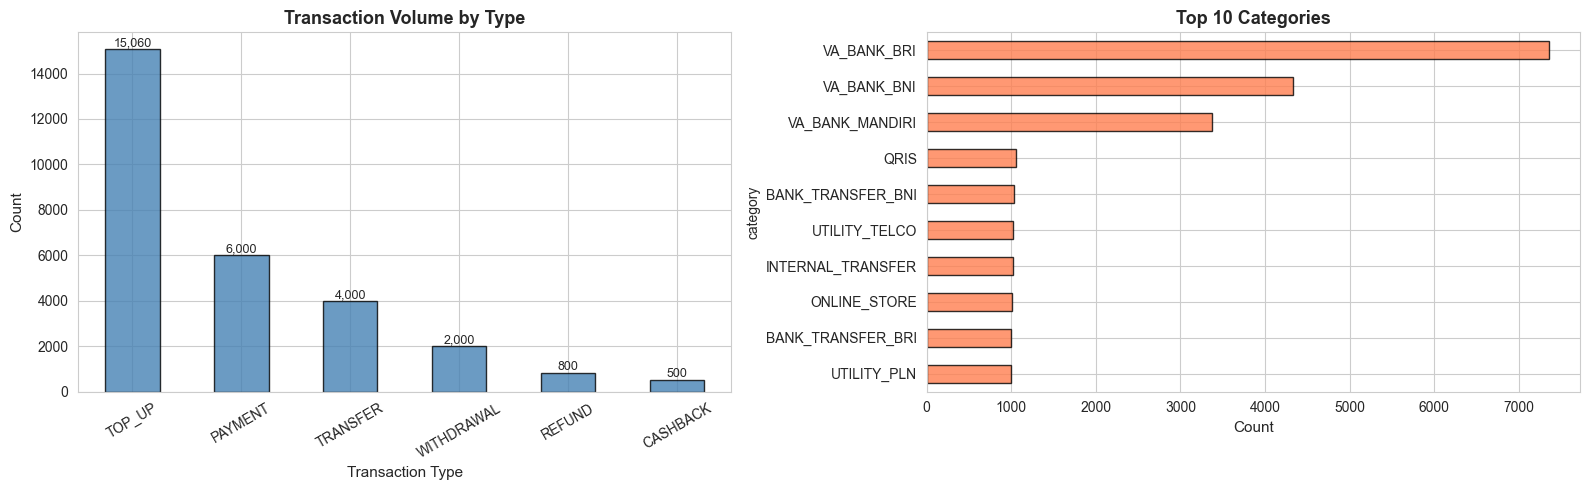

transaction_type
TOP_UP        15060
PAYMENT        6000
TRANSFER       4000
WITHDRAWAL     2000
REFUND          800
CASHBACK        500

→ TOP_UP dominates (53%). Class imbalance relevant for any classification task.


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

type_counts = df['transaction_type'].value_counts()
type_counts.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8, edgecolor='black')
axes[0].set_title('Transaction Volume by Type', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f'{int(bar.get_height()):,}',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

cat_counts = df['category'].value_counts().head(10)
cat_counts.plot(kind='barh', ax=axes[1], color='coral', alpha=0.8, edgecolor='black')
axes[1].set_title('Top 10 Categories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print(type_counts.to_string())
print()
print('→ TOP_UP dominates (53%). Class imbalance relevant for any classification task.')

## Part 3: Financial Amount Analysis

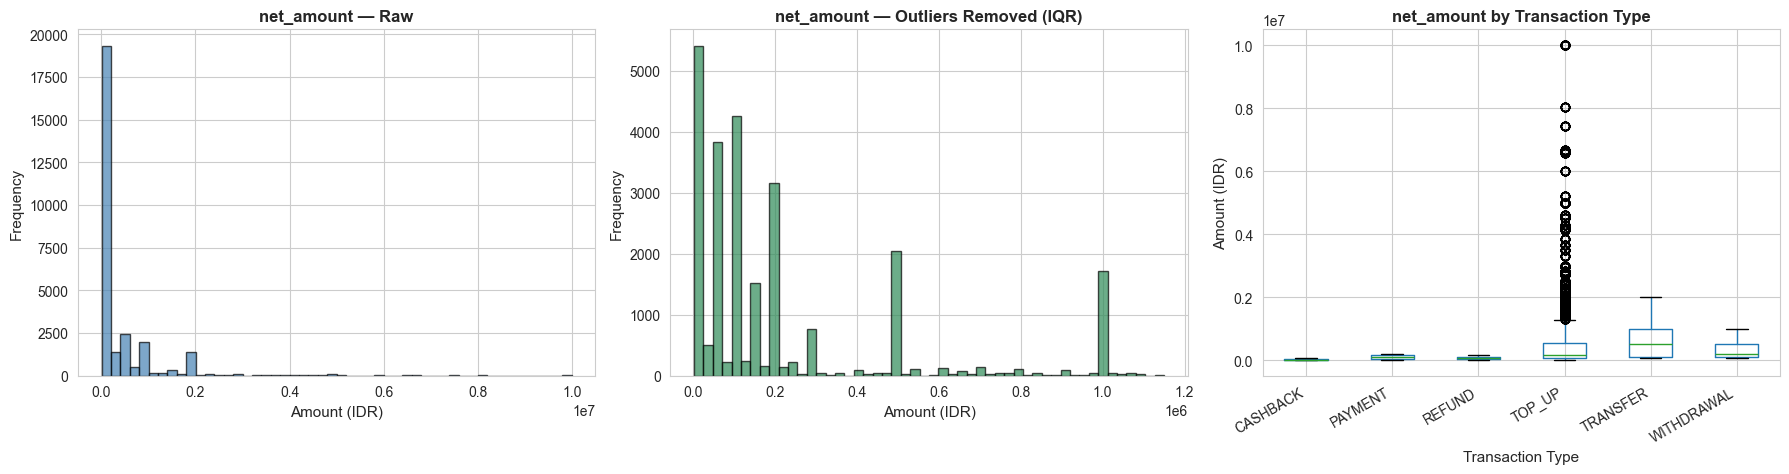

Original   : 28,360 transactions
No outliers: 25,703 transactions
Removed    : 2,657 (9.4%)

Amount Statistics by Transaction Type (IDR):
                     count       mean          std       min        25%        50%          75%           max
transaction_type                                                                                             
CASHBACK            500.00  18,415.00    14,548.00  2,500.00   5,000.00  15,000.00    25,000.00     50,000.00
PAYMENT           6,000.00  89,755.00    70,521.00 10,000.00  20,000.00 100,000.00   150,000.00    200,000.00
REFUND              800.00  65,888.00    53,493.00 10,000.00  20,000.00  50,000.00   100,000.00    150,000.00
TOP_UP           15,060.00 548,138.00 1,035,957.00 10,000.00  50,000.00 150,000.00   550,000.00 10,000,000.00
TRANSFER          4,000.00 667,600.00   701,304.00 50,000.00 100,000.00 500,000.00 1,000,000.00  2,000,000.00
WITHDRAWAL        2,000.00 346,825.00   322,259.00 50,000.00 100,000.00 200,000.00   500,000

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
amounts = df['net_amount'].dropna().astype(float)

# Remove outliers using IQR for visualisation only — df is NOT mutated
Q1  = amounts.quantile(0.25)
Q3  = amounts.quantile(0.75)
IQR = Q3 - Q1
amounts_no_outliers = amounts[(amounts >= Q1 - 1.5 * IQR) & (amounts <= Q3 + 1.5 * IQR)]

# Graph 1: Raw
axes[0].hist(amounts, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('net_amount — Raw', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Amount (IDR)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# Graph 2: Outliers removed
axes[1].hist(amounts_no_outliers, bins=50, color='seagreen', alpha=0.7, edgecolor='black')
axes[1].set_title('net_amount — Outliers Removed (IQR)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Amount (IDR)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)

# Graph 3: Box plot by transaction type — throwaway copy, df is NOT mutated
box_data = df[['transaction_type', 'net_amount']].copy()
box_data['net_amount'] = box_data['net_amount'].astype(float)
box_data.boxplot(column='net_amount', by='transaction_type', ax=axes[2])
axes[2].set_title('net_amount by Transaction Type', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Transaction Type', fontsize=11)
axes[2].set_ylabel('Amount (IDR)', fontsize=11)
plt.sca(axes[2])
plt.xticks(rotation=30, ha='right')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f'Original   : {len(amounts):,} transactions')
print(f'No outliers: {len(amounts_no_outliers):,} transactions')
print(f'Removed    : {len(amounts) - len(amounts_no_outliers):,} ({(1 - len(amounts_no_outliers)/len(amounts))*100:.1f}%)')
print()
print('Amount Statistics by Transaction Type (IDR):')
print(df.groupby('transaction_type')['net_amount'].describe().round(0).to_string())
print()
print('→ Outlier removal is for visualisation only — df is unchanged.')
print('→ Decision on outlier treatment (keep, drop, cap) is made in transformation stage.')

## Part 4: Fee Analysis

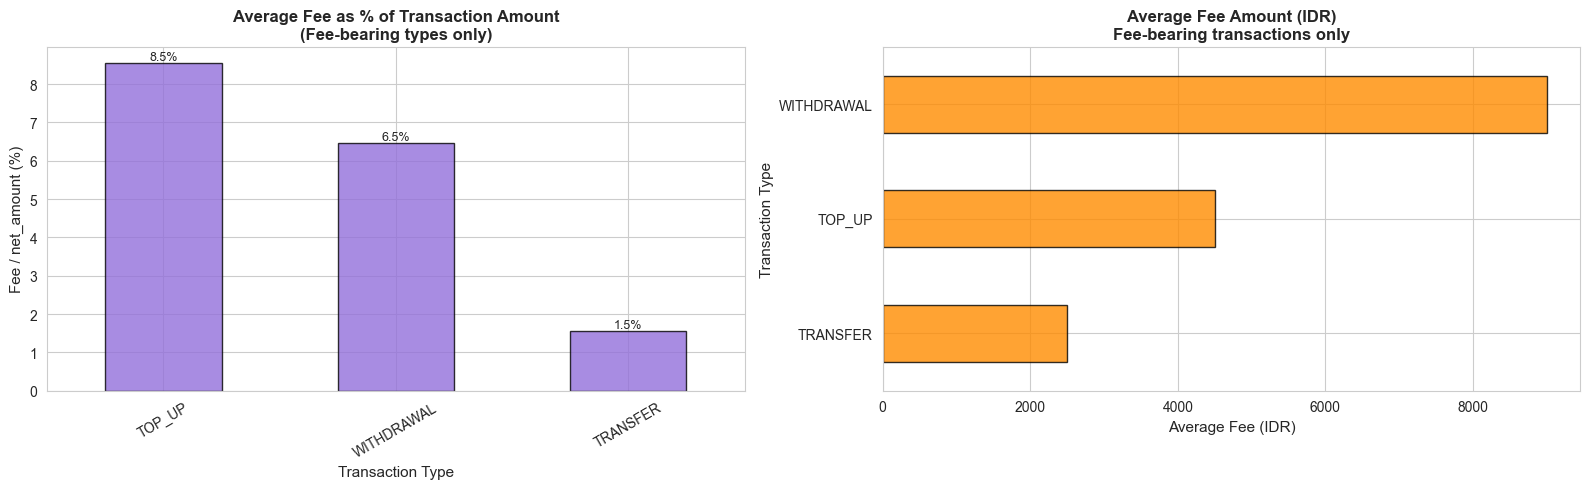

                    sum  count  pct_with_fee
transaction_type                            
CASHBACK              0    500          0.00
PAYMENT               0   6000          0.00
REFUND                0    800          0.00
TOP_UP            15060  15060        100.00
TRANSFER           4000   4000        100.00
WITHDRAWAL         2000   2000        100.00

→ WITHDRAWAL has the highest absolute fee but TRANSFER may carry a higher fee burden relative to amount.
→ Transformation Decision: Create fee_ratio feature to capture proportional cost.


In [56]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Graph 1: Fee burden — average fee as % of transaction amount by type
fee_burden = df[df['total_fee'] > 0].copy()
fee_burden['fee_ratio'] = fee_burden['total_fee'].astype(float) / fee_burden['net_amount'].astype(float) * 100

avg_burden = fee_burden.groupby('transaction_type')['fee_ratio'].mean().sort_values(ascending=False)

avg_burden.plot(kind='bar', ax=axes[0], color='mediumpurple', alpha=0.8, edgecolor='black')
axes[0].set_title('Average Fee as % of Transaction Amount\n(Fee-bearing types only)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=11)
axes[0].set_ylabel('Fee / net_amount (%)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
for bar in axes[0].patches:
    axes[0].annotate(f'{bar.get_height():.1f}%',
                     (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                     ha='center', va='bottom', fontsize=9)

# Graph 2: Average absolute fee amount by transaction type (fee-bearing only)
avg_fee = df[df['total_fee'] > 0].groupby('transaction_type')['total_fee'].mean().sort_values()
avg_fee.plot(kind='barh', ax=axes[1], color='darkorange', alpha=0.8, edgecolor='black')
axes[1].set_title('Average Fee Amount (IDR)\nFee-bearing transactions only', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Average Fee (IDR)', fontsize=11)
axes[1].set_ylabel('Transaction Type', fontsize=11)

plt.tight_layout()
plt.show()

print(fee_by_type.to_string())
print()
print('→ WITHDRAWAL has the highest absolute fee but TRANSFER may carry a higher fee burden relative to amount.')
print('→ Transformation Decision: Create fee_ratio feature to capture proportional cost.')

## Part 5: Temporal Patterns

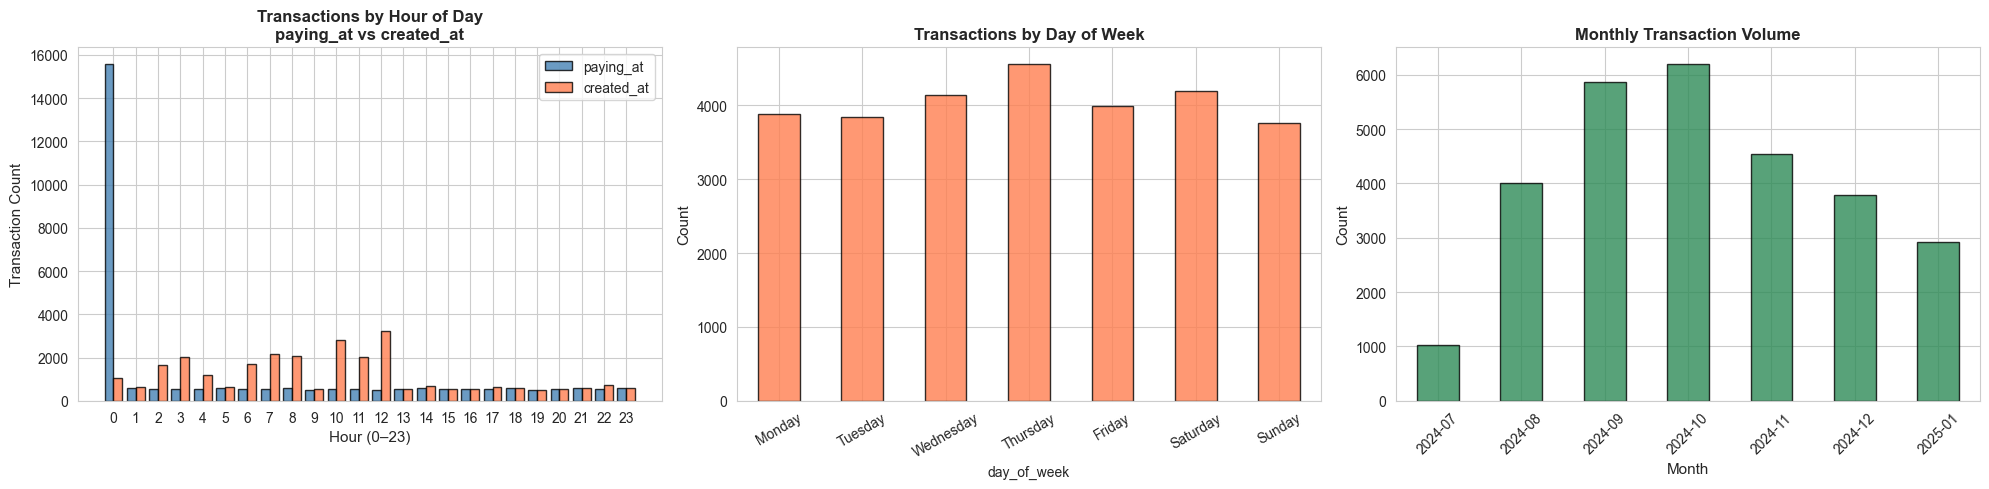

Peak hour: 0 (15,585 transactions)
Peak day : Thursday (4,561 transactions)

→ Transformation Decision: Extract hour, day_of_week, is_weekend, month as features.


In [76]:
df['hour']        = df['paying_at'].dt.hour
df['day_of_week'] = df['paying_at'].dt.day_name()
df['month']       = df['paying_at'].dt.to_period('M').astype(str)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Graph 1: Hourly volume — paying_at vs created_at overlaid
hourly_paying  = df.groupby(df['paying_at'].dt.hour).size()
hourly_created = df.groupby(df['created_at'].dt.hour).size()
x = range(24)
width = 0.4
axes[0].bar([i - width/2 for i in x], hourly_paying, width=width,
            color='steelblue', alpha=0.8, edgecolor='black', label='paying_at')
axes[0].bar([i + width/2 for i in x], hourly_created, width=width,
            color='coral', alpha=0.8, edgecolor='black', label='created_at')
axes[0].set_title('Transactions by Hour of Day\npaying_at vs created_at', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour (0–23)', fontsize=11)
axes[0].set_ylabel('Transaction Count', fontsize=11)
axes[0].set_xticks(x)
axes[0].legend()

# Graph 2: Transactions by Day of the Week
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow = df.groupby('day_of_week').size().reindex(dow_order)
dow.plot(kind='bar', ax=axes[1], color='coral', alpha=0.8, edgecolor='black')
axes[1].set_title('Transactions by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].tick_params(axis='x', rotation=30)

# Graph 3: Monthly Transaction Volume
monthly = df.groupby('month').size().sort_index()
monthly.plot(kind='bar', ax=axes[2], color='seagreen', alpha=0.8, edgecolor='black')
axes[2].set_title('Monthly Transaction Volume', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Month', fontsize=11)
axes[2].set_ylabel('Count', fontsize=11)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'Peak hour: {hourly.idxmax()} ({hourly.max():,} transactions)')
print(f'Peak day : {dow.idxmax()} ({dow.max():,} transactions)')
print()
print('→ Transformation Decision: Extract hour, day_of_week, is_weekend, month as features.')

## Part 6: Categorical Association (Chi-Square)

In [58]:
cat_pairs = [
    ('transaction_type', 'channel'),
    ('transaction_type', 'journal_type'),
    ('channel',          'journal_type'),
]

print('Chi-Square Association Tests')
print('=' * 65)
print(f'{"Variable 1":<22} {"Variable 2":<18} {"Chi2":>10} {"p-value":>12} {"Decision"}')
print('-' * 65)

for v1, v2 in cat_pairs:
    ct = pd.crosstab(df[v1], df[v2])
    chi2, p, dof, _ = chi2_contingency(ct)
    if p > 0.05:
        decision = 'Separate features'
    elif p < 0.05 and len(df) < 1000:
        decision = 'Combined features'
    else:
        decision = 'Interaction terms'
    print(f'{v1:<22} {v2:<18} {chi2:>10.1f} {p:>12.4f}  {decision}')

print()
print(f'Dataset size: {len(df):,} rows → large dataset threshold applies (>5,000)')

Chi-Square Association Tests
Variable 1             Variable 2               Chi2      p-value Decision
-----------------------------------------------------------------
transaction_type       channel               82524.6       0.0000  Interaction terms
transaction_type       journal_type          28360.0       0.0000  Interaction terms
channel                journal_type          20148.3       0.0000  Interaction terms

Dataset size: 28,360 rows → large dataset threshold applies (>5,000)


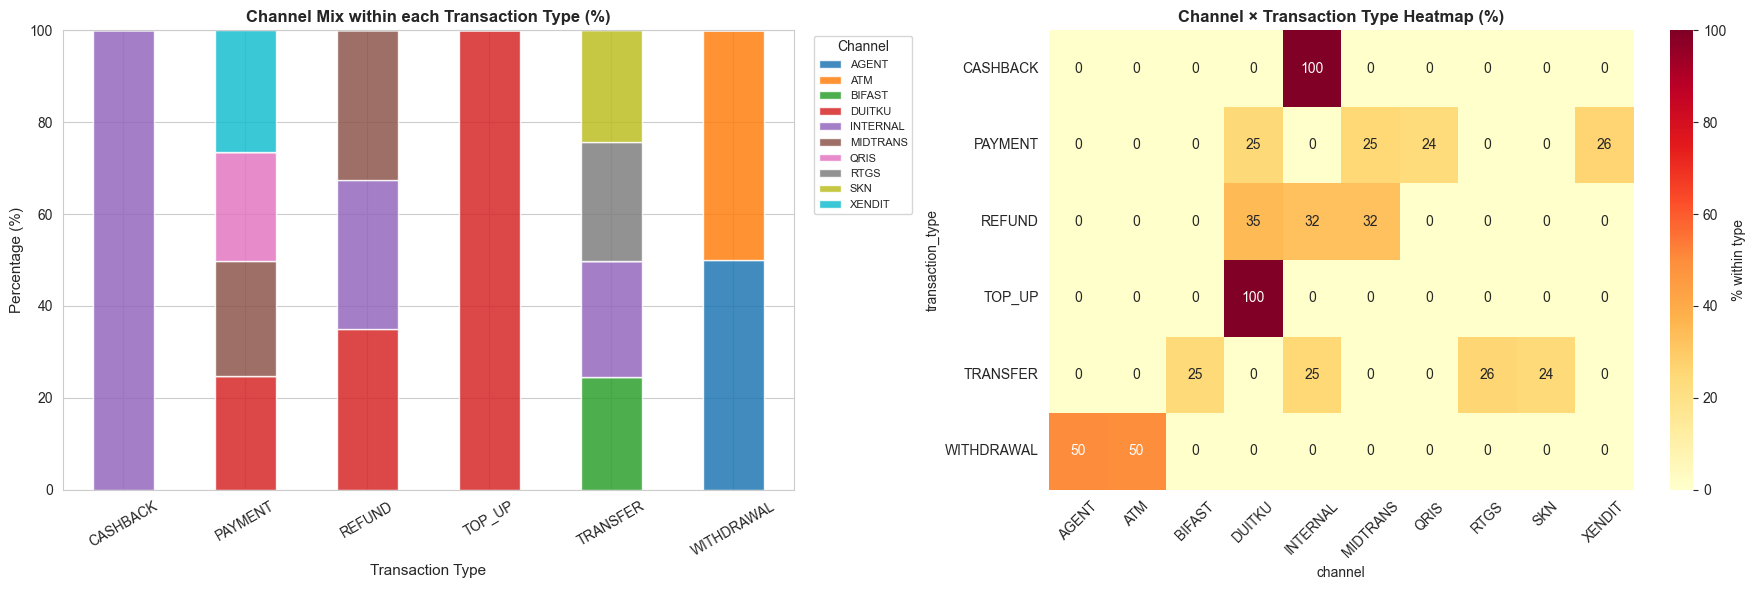

→ Non-uniform bars = strong association confirmed between channel and transaction type.


In [31]:
crosstab_pct = pd.crosstab(df['transaction_type'], df['channel'], normalize='index') * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

crosstab_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', alpha=0.85)
axes[0].set_title('Channel Mix within each Transaction Type (%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Transaction Type', fontsize=11)
axes[0].set_ylabel('Percentage (%)', fontsize=11)
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

sns.heatmap(crosstab_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=axes[1], cbar_kws={'label': '% within type'})
axes[1].set_title('Channel × Transaction Type Heatmap (%)', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()
print('→ Non-uniform bars = strong association confirmed between channel and transaction type.')

## Part 7: Outlier Detection

In [32]:
print('Outlier Detection — IQR Method')
print('=' * 55)

for col in ['net_amount', 'total_fee']:
    series = df[col].dropna().astype(float)
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((series < lo) | (series > hi)).sum()
    pct    = n_out / len(series) * 100
    print(f'\n{col}')
    print(f'  IQR bounds : [{lo:,.0f}, {hi:,.0f}]')
    print(f'  Outliers   : {n_out:,}  ({pct:.1f}%)')
    if pct < 1:
        print('  → < 1% — keep; flag with is_large_tx')
    elif pct < 5:
        print('  → 1–5% — investigate; consider winsorising')
    else:
        print('  → > 5% — review data quality')

Outlier Detection — IQR Method

net_amount
  IQR bounds : [-625,000, 1,175,000]
  Outliers   : 2,657  (9.4%)
  → > 5% — review data quality

total_fee
  IQR bounds : [-6,750, 11,250]
  Outliers   : 0  (0.0%)
  → < 1% — keep; flag with is_large_tx


## Part 8: Wallet-Level Behaviour

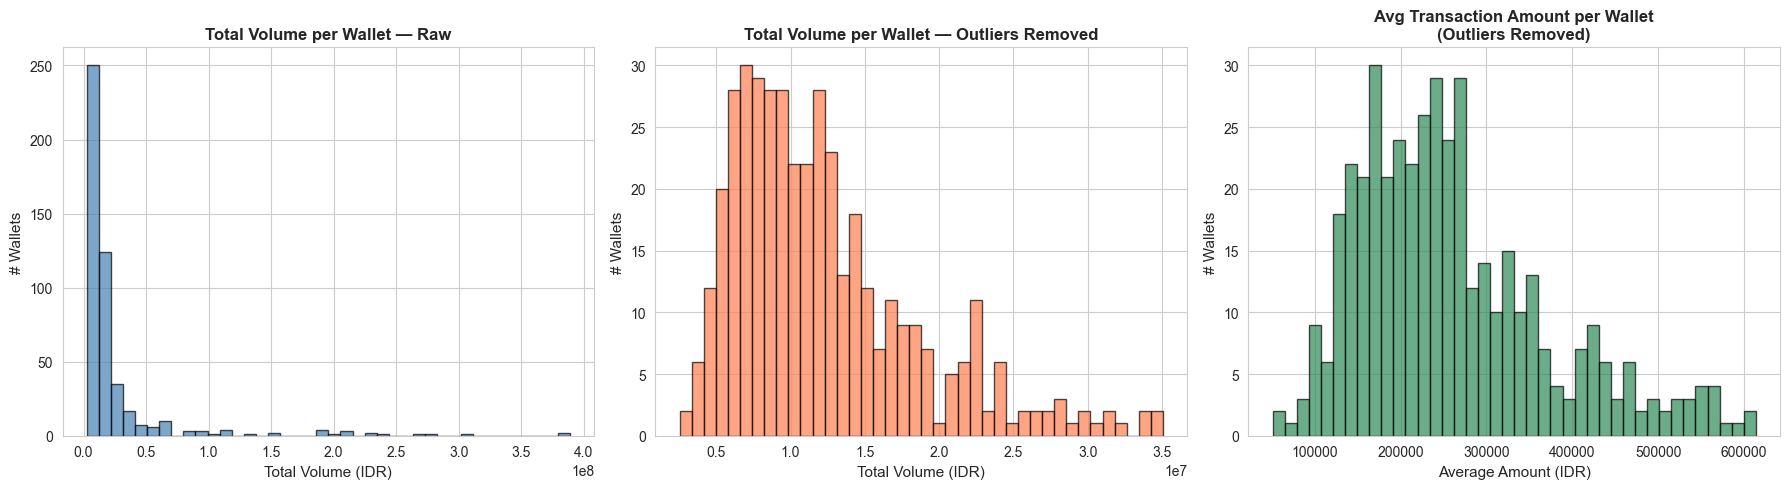

       tx_count   total_volume   avg_amount  unique_types  unique_channels
count    479.00         479.00       479.00        479.00           479.00
mean      59.20  25,510,340.50   358,546.90          5.40             9.30
std       52.90  46,958,378.30   381,346.70          0.60             0.80
min       27.00   2,530,000.00    50,746.30          3.00             6.00
25%       39.00   8,062,500.00   182,867.60          5.00             9.00
50%       45.00  11,955,000.00   250,357.10          6.00             9.00
75%       59.00  18,940,000.00   357,446.80          6.00            10.00
max      792.00 389,110,000.00 3,569,816.50          6.00            10.00

Total volume outliers removed : 63 wallets (13.2%)
Avg amount outliers removed   : 48 wallets (10.0%)

→ Average transaction amount reveals wallet behaviour — high avg = transfers/withdrawals, low avg = payments/top-ups.
→ Transformation Decision: Aggregate wallet features for wallet-level modelling.


In [34]:
wallet_stats = df.groupby('wallet_id').agg(
    tx_count        = ('transaction_id', 'count'),
    total_volume    = ('net_amount', 'sum'),
    avg_amount      = ('net_amount', 'mean'),
    unique_types    = ('transaction_type', 'nunique'),
    unique_channels = ('channel', 'nunique'),
).reset_index()

# IQR outlier removal for visualisation only — wallet_stats is NOT mutated
tv = wallet_stats['total_volume'].astype(float)
Q1, Q3 = tv.quantile(0.25), tv.quantile(0.75)
IQR = Q3 - Q1
tv_no_outliers = tv[(tv >= Q1 - 1.5 * IQR) & (tv <= Q3 + 1.5 * IQR)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Raw total volume
axes[0].hist(tv, bins=40, color='steelblue', alpha=0.7, edgecolor='black')
axes[0].set_title('Total Volume per Wallet — Raw', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Volume (IDR)', fontsize=11)
axes[0].set_ylabel('# Wallets', fontsize=11)

# Graph 2: Total volume outliers removed
axes[1].hist(tv_no_outliers, bins=40, color='coral', alpha=0.7, edgecolor='black')
axes[1].set_title('Total Volume per Wallet — Outliers Removed', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Total Volume (IDR)', fontsize=11)
axes[1].set_ylabel('# Wallets', fontsize=11)

# Graph 3: Average transaction amount per wallet — shows spending behaviour
# High avg = wallet used for large transfers, low avg = wallet used for small payments
avg = wallet_stats['avg_amount'].astype(float)
Q1a, Q3a = avg.quantile(0.25), avg.quantile(0.75)
IQRa = Q3a - Q1a
avg_no_outliers = avg[(avg >= Q1a - 1.5 * IQRa) & (avg <= Q3a + 1.5 * IQRa)]

axes[2].hist(avg_no_outliers, bins=40, color='seagreen', alpha=0.7, edgecolor='black')
axes[2].set_title('Avg Transaction Amount per Wallet\n(Outliers Removed)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Average Amount (IDR)', fontsize=11)
axes[2].set_ylabel('# Wallets', fontsize=11)

plt.tight_layout()
plt.show()

print(wallet_stats.describe().round(1).to_string())
print()
print(f'Total volume outliers removed : {len(tv) - len(tv_no_outliers):,} wallets ({(1 - len(tv_no_outliers)/len(tv))*100:.1f}%)')
print(f'Avg amount outliers removed   : {len(avg) - len(avg_no_outliers):,} wallets ({(1 - len(avg_no_outliers)/len(avg))*100:.1f}%)')
print()
print('→ Average transaction amount reveals wallet behaviour — high avg = transfers/withdrawals, low avg = payments/top-ups.')
print('→ Transformation Decision: Aggregate wallet features for wallet-level modelling.')

## EDA Summary

| # | Finding | Transformation Action |
|---|---|---|
| 1 | `net_amount` right-skewed | `log1p(net_amount)` |
| 2 | `total_fee = 0` for TOP_UP | `has_fee` binary flag |
| 3 | Hourly & weekly patterns | `hour`, `day_of_week`, `is_weekend` |
| 4 | Strong `channel` × `transaction_type` association | Interaction terms |
| 5 | `journal_type` redundant | Drop column |
| 6 | Outliers <1% in `net_amount` | `is_large_tx` flag |
| 7 | `status` has zero variance | Drop column |
| 8 | Wallet behaviour varies widely | Aggregated wallet features |

---
# SECTION 3 — TRANSFORMATION

Every step below is directly traceable to an EDA finding above.

In [77]:
# Start from df_raw to apply transformations cleanly
df = df_raw.copy()
print(f'Starting transformation. Shape: {df.shape}')

Starting transformation. Shape: (28360, 24)


In [78]:
# Step 1: Drop redundant / zero-variance columns
# EDA: status always '00', journal_type maps 1-to-1 with transaction_type
cols_before = df.columns.tolist()
df = df.drop(columns=['status', 'journal_type'])
print(f'Dropped: {set(cols_before) - set(df.columns)}')
print(f'Shape  : {df.shape}')

Dropped: {'journal_type', 'status'}
Shape  : (28360, 22)


In [81]:
# Step 2: Temporal features
# EDA: volume peaks at specific hours/days
df['hour']           = df['created_at'].dt.hour
df['day_of_week']    = df['created_at'].dt.dayofweek  # 0=Monday, 6=Sunday
df['is_weekend']     = df['day_of_week'].isin([5, 6]).astype(int)
df['month']          = df['created_at'].dt.month

print('Temporal features created:')
print(df[['created_at', 'hour', 'day_of_week', 'is_weekend', 'month']].head(10).to_string())

Temporal features created:
           created_at  hour  day_of_week  is_weekend  month
0 2024-07-17 23:54:56    23            2           0      7
1 2024-07-18 00:07:22     0            3           0      7
2 2024-07-18 00:21:36     0            3           0      7
3 2024-07-18 00:35:25     0            3           0      7
4 2024-07-18 00:44:21     0            3           0      7
5 2024-07-18 00:56:58     0            3           0      7
6 2024-07-18 02:07:12     2            3           0      7
7 2024-07-18 01:59:26     1            3           0      7
8 2024-07-18 02:28:09     2            3           0      7
9 2024-07-18 03:02:31     3            3           0      7


In [82]:
# Step 3: Financial features
# EDA: right-skewed amounts, meaningful zero-fee pattern, <1% outliers
df['log_net_amount'] = np.log1p(df['net_amount'].astype(float))
df['log_total_fee']  = np.log1p(df['total_fee'].astype(float))
df['has_fee']        = (df['total_fee'] > 0).astype(int)
df['fee_ratio']      = np.where(
    df['net_amount'] > 0,
    df['total_fee'].astype(float) / df['net_amount'].astype(float),
    0.0
)
p99 = df['net_amount'].astype(float).quantile(0.99)
df['is_large_tx'] = (df['net_amount'].astype(float) > p99).astype(int)

print(f'p99 threshold : IDR {p99:,.0f}')
print(f'Large tx flagged: {df["is_large_tx"].sum():,} ({df["is_large_tx"].mean()*100:.1f}%)')

p99 threshold : IDR 4,200,000
Large tx flagged: 277 (1.0%)


In [83]:
# Step 4a: One-hot encoding
# EDA: transaction_type, channel, category have no natural order
df_encoded = pd.get_dummies(
    df,
    columns=['transaction_type', 'channel', 'category'],
    prefix=['type', 'ch', 'cat'],
    drop_first=True
)
df_encoded['is_verified'] = df_encoded['is_verified'].astype(int)

new_ohe = [c for c in df_encoded.columns if c.startswith(('type_','ch_','cat_'))]
print(f'One-hot columns created: {len(new_ohe)}')
print(f'Shape after OHE        : {df_encoded.shape}')

One-hot columns created: 36
Shape after OHE        : (28360, 64)


In [84]:
# Step 4b: Interaction term — transaction_type × channel
# EDA: strong chi-square association + large dataset (28k rows) → interaction terms
df['type_x_channel'] = df['transaction_type'].astype(str) + '__' + df['channel'].astype(str)
interaction_ohe = pd.get_dummies(df['type_x_channel'], prefix='ixn', drop_first=True)
df_encoded = pd.concat([df_encoded, interaction_ohe], axis=1)

print(f'Interaction columns created: {len(interaction_ohe.columns)}')
print(f'Shape after interactions   : {df_encoded.shape}')

Interaction columns created: 14
Shape after interactions   : (28360, 78)


In [85]:
# Step 5: Wallet-level aggregated features
# EDA: wallet behaviour varies widely
wallet_agg = df.groupby('wallet_id').agg(
    wallet_tx_count     = ('transaction_id', 'count'),
    wallet_total_volume = ('net_amount', lambda x: x.astype(float).sum()),
    wallet_avg_amount   = ('net_amount', lambda x: x.astype(float).mean()),
    wallet_unique_types = ('transaction_type', 'nunique'),
    wallet_unique_cats  = ('category', 'nunique'),
    wallet_fee_rate     = ('has_fee', 'mean'),
).reset_index()
wallet_agg['wallet_log_volume'] = np.log1p(wallet_agg['wallet_total_volume'])

df_encoded = df_encoded.merge(wallet_agg, on='wallet_id', how='left')
print(f'Wallet features added. Shape: {df_encoded.shape}')

Wallet features added. Shape: (28360, 85)


In [86]:
# Step 6: Drop raw/identifier columns no longer needed
drop_final = [
    'reference_number', 'partner_ref', 'receipt_number',
    'paying_at', 'created_at', 'updated_at',
    'type_x_channel',
    'note', 'detail',
]
df_final = df_encoded.drop(columns=[c for c in drop_final if c in df_encoded.columns])
print(f'Shape after clean-up: {df_final.shape}')

Shape after clean-up: (28360, 77)


In [87]:
# Step 7: Handle residual missing values
missing = df_final.isnull().sum()
missing = missing[missing > 0]

if len(missing) == 0:
    print('No missing values in final DataFrame. ✓')
else:
    for col in missing.index:
        if df_final[col].dtype in ['float64', 'Float64', 'Int64']:
            df_final[col] = df_final[col].fillna(df_final[col].median())
            print(f'  {col}: filled with median')
        else:
            df_final[col] = df_final[col].fillna('UNKNOWN')
            print(f'  {col}: filled with UNKNOWN')

No missing values in final DataFrame. ✓


In [88]:
# Step 8: Final validation
print('Transformation Validation')
print('=' * 50)
print(f'  Original rows  : {len(df_raw):,}')
print(f'  Final rows     : {len(df_final):,}  →  {"✓ PASS" if len(df_final) == len(df_raw) else "✗ FAIL"}')
print(f'  Missing values : {df_final.isnull().sum().sum()}  →  {"✓ PASS" if df_final.isnull().sum().sum() == 0 else "✗ FAIL"}')
print(f'  Total columns  : {df_final.shape[1]}')
print()
numeric_feats = df_final.select_dtypes(include='number').columns.tolist()
obj_feats     = df_final.select_dtypes(include='object').columns.tolist()
print(f'  Numeric features : {len(numeric_feats)}')
print(f'  Object columns   : {len(obj_feats)}  {obj_feats}')

Transformation Validation
  Original rows  : 28,360
  Final rows     : 28,360  →  ✓ PASS
  Missing values : 0  →  ✓ PASS
  Total columns  : 77

  Numeric features : 23
  Object columns   : 4  ['wallet_id', 'phone_number', 'currency', 'channel_ref']


C:\Users\fh81\AppData\Local\Temp\ipykernel_15384\1982508118.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_feats     = df_final.select_dtypes(include='object').columns.tolist()


In [89]:
print('df_final is ready for Storage.')
print(f'Shape : {df_final.shape}')
print(f'Memory: {df_final.memory_usage(deep=True).sum() / 1_024 / 1_024:.2f} MB')
df_final.head(3)

df_final is ready for Storage.
Shape : (28360, 77)
Memory: 8.81 MB


,transaction_id,customer_id,wallet_id,phone_number,net_amount,fee_internal,fee_external,total_fee,currency,channel_ref,...,ixn_TRANSFER__SKN,ixn_WITHDRAWAL__AGENT,ixn_WITHDRAWAL__ATM,wallet_tx_count,wallet_total_volume,wallet_avg_amount,wallet_unique_types,wallet_unique_cats,wallet_fee_rate,wallet_log_volume
0,1,4837,WLT-00000020,85792621011,100000,2500,6500,9000,IDR,85117b82-1488-4c2c-b36b-9533e2f802cb,...,False,False,True,42,"13,420,000.00","319,523.81",6,17,0.64,16.41
1,2,7175,WLT-00001408,89675380709,10000,0,0,0,IDR,e44e3450-c272-4db7-9717-c99108d34589,...,False,False,False,40,"6,110,000.00","152,750.00",5,14,0.50,15.63
2,3,33065,WLT-00001053,85213237846,150000,0,0,0,IDR,3d0028b6-6532-4cc8-addd-f1b73a743c8e,...,False,False,False,49,"20,925,000.00","427,040.82",6,17,0.67,16.86


---
## Pipeline Summary

| Stage | Input | Output |
|---|---|---|
| **Ingestion** | XML file (Google Drive) | `df_raw` — 28,360 rows, 23 cols |
| **EDA** | `df_raw` | 8 transformation decisions |
| **Transformation** | `df_raw` | `df_final` — 28,360 rows, engineered features |

**Next step → Storage:** write `df_final` to your database or file store.